In [1]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [2]:
data = pd.read_csv('diabetes.csv')

print(data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
# Check if there are missing values
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [4]:
# In diabetes dataset, 0 values are often invalid
columns_to_fix = ['Glucose', 'BloodPressure', 'BMI']

for col in columns_to_fix:
    data[col] = data[col].replace(0, data[col].mean())

# Bar Chart

In [5]:
bar_data = data.groupby('Outcome')['Glucose'].mean().reset_index()

bar_fig = px.bar(bar_data, x='Outcome', y='Glucose',
                 title="Average Glucose by Outcome")

# Scatter Plot

In [6]:
scatter_fig = px.scatter(data, x='Glucose', y='BMI',
                         color='Outcome',
                         title="Glucose vs BMI")

# Pie Chart

In [7]:
pie_data = data['Outcome'].value_counts().reset_index()
pie_data.columns = ['Outcome', 'Count']

# Convert 0/1 to meaningful labels
pie_data['Outcome'] = pie_data['Outcome'].map({
    0: "Non-Diabetic",
    1: "Diabetic"
})


pie_fig = px.pie(
    pie_data,
    names='Outcome',
    values='Count',
    title="Diabetes Distribution"
)

# Histogram

In [14]:
hist_fig = px.histogram(data, x='Glucose',
                        nbins=10,
                        title="Glucose Distribution")

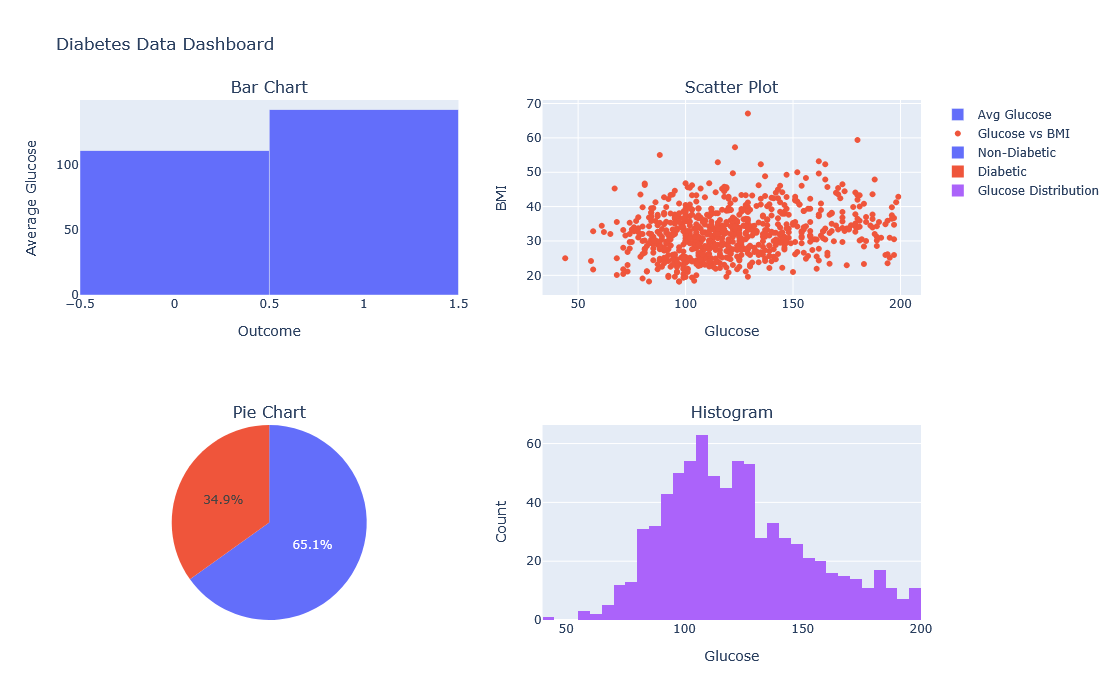

In [15]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Bar Chart", "Scatter Plot", "Pie Chart", "Histogram"),
    specs=[[{"type": "xy"}, {"type": "xy"}],
           [{"type": "domain"}, {"type": "xy"}]]
)

# ✅ Bar Chart (with name)
fig.add_trace(
    go.Bar(
        x=bar_data['Outcome'],
        y=bar_data['Glucose'],
        name="Avg Glucose"
    ),
    row=1, col=1
)

# ✅ Scatter Plot (with proper legend)
fig.add_trace(
    go.Scatter(
        x=data['Glucose'],
        y=data['BMI'],
        mode='markers',
        name="Glucose vs BMI"
    ),
    row=1, col=2
)

# ✅ Pie Chart
fig.add_trace(
    go.Pie(
        labels=pie_data['Outcome'],
        values=pie_data['Count'],
        name="Distribution"
    ),
    row=2, col=1
)

# ✅ Histogram
fig.add_trace(
    go.Histogram(
        x=data['Glucose'],
        name="Glucose Distribution"
    ),
    row=2, col=2
)

# 🎯 Axis labels (IMPORTANT PART)
fig.update_xaxes(title_text="Outcome", row=1, col=1)
fig.update_yaxes(title_text="Average Glucose", row=1, col=1)

fig.update_xaxes(title_text="Glucose", row=1, col=2)
fig.update_yaxes(title_text="BMI", row=1, col=2)

fig.update_xaxes(title_text="Glucose", row=2, col=2)
fig.update_yaxes(title_text="Count", row=2, col=2)

# 🎯 Layout
fig.update_layout(
    height=700,
    width=900,
    title_text="Diabetes Data Dashboard",
    showlegend=True
)

fig.show()